# DriftBench-TS: Comprehensive Results Analysis

This notebook analyzes experiment results across all datasets, models, and retraining strategies.

## Key Questions Answered:
- Which model performs best overall?
- When does adaptive retraining outperform fixed?
- What's the accuracy-cost trade-off?
- How do different strategies compare?

In [2]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

RESULTS_DIR = '../results'

## 1. Load All Results

In [3]:
def load_all_results(results_dir):
    results = []
    for root, dirs, files in os.walk(results_dir):
        if 'metrics.json' in files:
            parts = root.split('/')
            if len(parts) >= 3:
                dataset, strategy, model = parts[-3], parts[-2], parts[-1]
                with open(os.path.join(root, 'metrics.json')) as f:
                    metrics = json.load(f)
                
                # Load retrain counts
                retrain_path = os.path.join(root, 'retraining_log.csv')
                retrain_count = 0
                if os.path.exists(retrain_path):
                    df = pd.read_csv(retrain_path)
                    retrain_count = len(df[df.get('reason', '') != 'initial_training']) if 'reason' in df.columns else len(df)
                
                results.append({
                    'dataset': dataset,
                    'strategy': strategy,
                    'model': model,
                    'mae': metrics.get('mae', 0),
                    'rmse': metrics.get('rmse', 0),
                    'smape': metrics.get('smape', 0),
                    'retrain_count': retrain_count
                })
    return pd.DataFrame(results)

df = load_all_results(RESULTS_DIR)
print(f"Loaded {len(df)} experiment runs")
print(f"Datasets: {df['dataset'].unique()}")
print(f"Models: {df['model'].unique()}")
print(f"Strategies: {df['strategy'].unique()}")
df.head()

Loaded 77 experiment runs
Datasets: <StringArray>
['..', 'wti', 'traffic', 'electricity', 'brent']
Length: 5, dtype: str
Models: <StringArray>
[     'test_lgbm',             'rf',          'naive',           'lstm',
           'lgbm',        'tsmixer', 'seasonal_naive',   'test_tsmixer',
        'test_sn',      'test_lstm',           'test']
Length: 11, dtype: str
Strategies: <StringArray>
['results', 'no_retrain', 'adaptive_retrain', 'fixed_retrain']
Length: 4, dtype: str


,dataset,strategy,model,mae,rmse,smape,retrain_count
0,..,results,test_lgbm,212.707533,385.797543,9.786708,0
1,wti,no_retrain,rf,20.207364,30.758684,34.803785,0
2,wti,no_retrain,naive,32.735549,43.211059,73.964365,0
3,wti,no_retrain,lstm,25.243977,30.823083,52.700141,0
4,wti,no_retrain,lgbm,18.176232,29.448949,31.679252,0


## 2. Model Rankings (Average MAE Across All Datasets)

In [4]:
model_rankings = df.groupby('model').agg({
    'mae': 'mean',
    'rmse': 'mean',
    'smape': 'mean'
}).round(2).sort_values('mae')

model_rankings['rank'] = range(1, len(model_rankings) + 1)
print("=== MODEL RANKINGS (by average MAE) ===")
print(model_rankings)

=== MODEL RANKINGS (by average MAE) ===
                    mae     rmse  smape  rank
model                                        
lgbm             206.72   406.24  18.64     1
test_lgbm        212.71   385.80   9.79     2
rf               269.47   479.55  22.07     3
test             344.16   564.26  14.05     4
tsmixer          437.13   647.57  24.65     5
seasonal_naive   841.26  1144.59  61.21     6
naive            933.56  1292.76  64.65     7
lstm             984.42  1324.19  60.88     8
test_tsmixer    1744.52  1986.04  63.40     9
test_sn         2180.64  2688.50  81.94    10
test_lstm       2819.30  3409.10  73.57    11


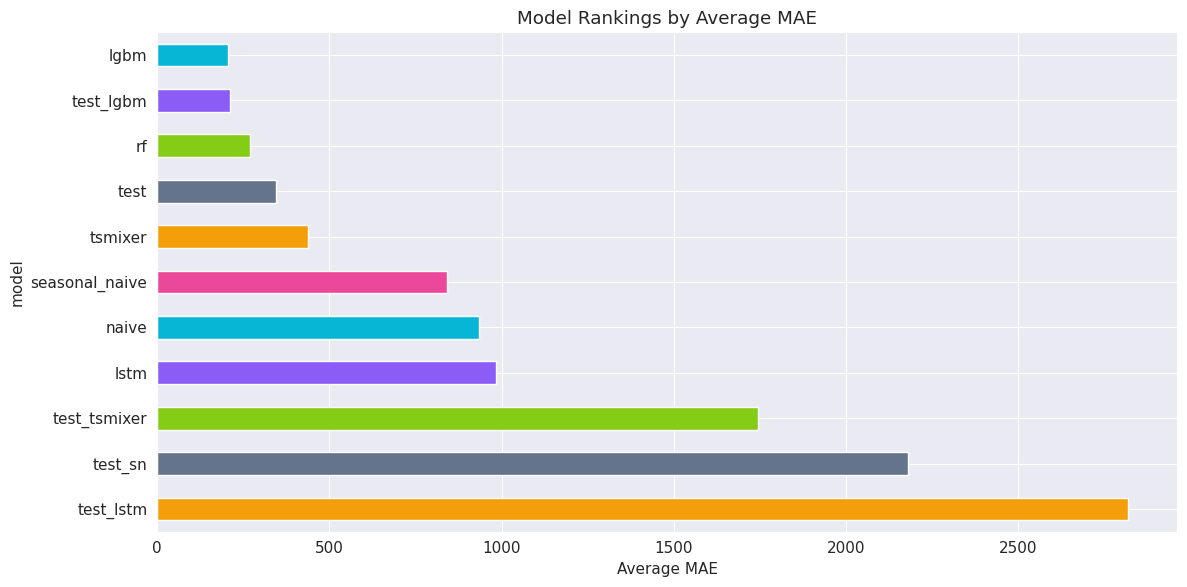

In [5]:
fig, ax = plt.subplots()
colors = ['#06b6d4', '#8b5cf6', '#84cc16', '#64748b', '#f59e0b', '#ec4899']
model_rankings['mae'].plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Average MAE')
ax.set_title('Model Rankings by Average MAE')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Strategy Rankings (Average MAE)

In [6]:
strategy_rankings = df.groupby('strategy').agg({
    'mae': 'mean',
    'rmse': 'mean',
    'retrain_count': 'sum'
}).round(2).sort_values('mae')

strategy_rankings['rank'] = range(1, len(strategy_rankings) + 1)
print("=== STRATEGY RANKINGS ===")
print(strategy_rankings)

=== STRATEGY RANKINGS ===
                      mae     rmse  retrain_count  rank
strategy                                               
fixed_retrain      475.67   693.32           4446     1
adaptive_retrain   584.50   811.66           4543     2
no_retrain         776.11  1142.47              0     3
results           1460.27  1806.74              0     4


## 4. When Does Adaptive Outperform Fixed?

In [7]:
# Compare adaptive vs fixed for each dataset/model combination
comparisons = []
for dataset in df['dataset'].unique():
    for model in df['model'].unique():
        adaptive = df[(df['dataset'] == dataset) & (df['model'] == model) & (df['strategy'] == 'adaptive_retrain')]
        fixed = df[(df['dataset'] == dataset) & (df['model'] == model) & (df['strategy'] == 'fixed_retrain')]
        
        if len(adaptive) > 0 and len(fixed) > 0:
            a_mae = adaptive['mae'].values[0]
            f_mae = fixed['mae'].values[0]
            improvement = (f_mae - a_mae) / f_mae * 100
            comparisons.append({
                'dataset': dataset,
                'model': model,
                'adaptive_mae': a_mae,
                'fixed_mae': f_mae,
                'improvement_pct': improvement,
                'winner': 'Adaptive' if improvement > 0 else 'Fixed'
            })

comp_df = pd.DataFrame(comparisons)
adaptive_wins = comp_df[comp_df['improvement_pct'] > 10].sort_values('improvement_pct', ascending=False)
print("=== CASES WHERE ADAPTIVE OUTPERFORMS FIXED (>10% improvement) ===")
print(adaptive_wins.to_string(index=False))

=== CASES WHERE ADAPTIVE OUTPERFORMS FIXED (>10% improvement) ===
    dataset   model  adaptive_mae  fixed_mae  improvement_pct   winner
      brent    lgbm      4.000781   7.273498        44.995093 Adaptive
      brent      rf      4.613304   8.126397        43.230631 Adaptive
        wti    lgbm      3.609255   5.851326        38.317315 Adaptive
        wti      rf      4.177229   6.750875        38.123146 Adaptive
electricity tsmixer    557.789127 633.485199        11.949146 Adaptive


In [8]:
# Summary by dataset
dataset_summary = comp_df.groupby('dataset').agg({
    'improvement_pct': 'mean',
    'winner': lambda x: (x == 'Adaptive').sum()
}).round(2)
dataset_summary.columns = ['avg_improvement', 'adaptive_wins_count']
print("\n=== SUMMARY BY DATASET ===")
print(dataset_summary)


=== SUMMARY BY DATASET ===
             avg_improvement  adaptive_wins_count
dataset                                          
brent                  17.78                    5
electricity           -33.83                    1
traffic               -21.74                    2
wti                    10.35                    2


## 5. Best Configuration Per Dataset

In [9]:
best_per_dataset = df.loc[df.groupby('dataset')['mae'].idxmin()]
print("=== BEST MODEL + STRATEGY PER DATASET ===")
print(best_per_dataset[['dataset', 'model', 'strategy', 'mae', 'retrain_count']].to_string(index=False))

=== BEST MODEL + STRATEGY PER DATASET ===
    dataset     model         strategy        mae  retrain_count
         .. test_lgbm          results 212.707533              0
      brent   tsmixer adaptive_retrain   1.393552             11
electricity      lgbm    fixed_retrain 119.526141            533
    traffic      lgbm adaptive_retrain 190.885006            494
        wti   tsmixer    fixed_retrain   1.368883              5


## 6. Heatmap: MAE by Dataset × Strategy

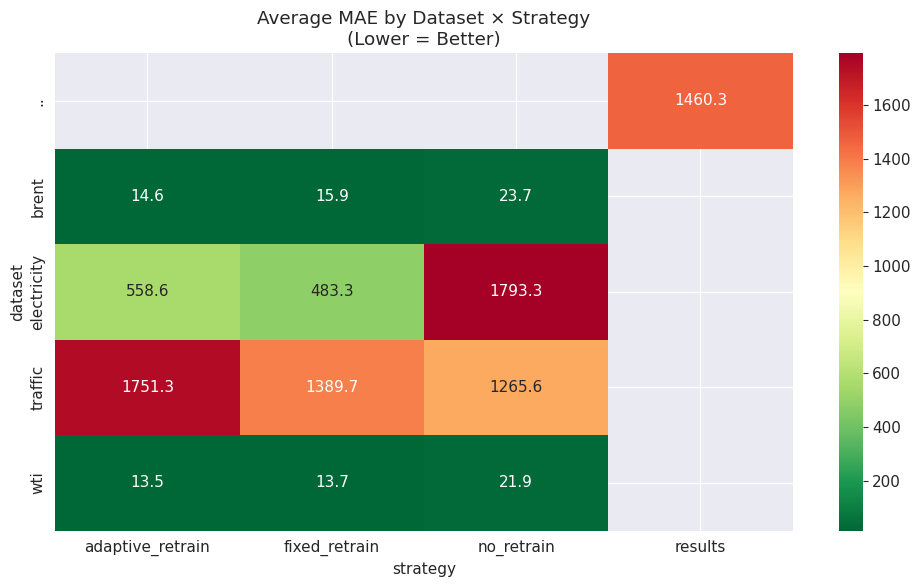

In [10]:
pivot = df.pivot_table(values='mae', index='dataset', columns='strategy', aggfunc='mean')
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax)
ax.set_title('Average MAE by Dataset × Strategy\n(Lower = Better)')
plt.tight_layout()
plt.show()

## 7. Efficiency Frontier: Error vs Retrain Cost

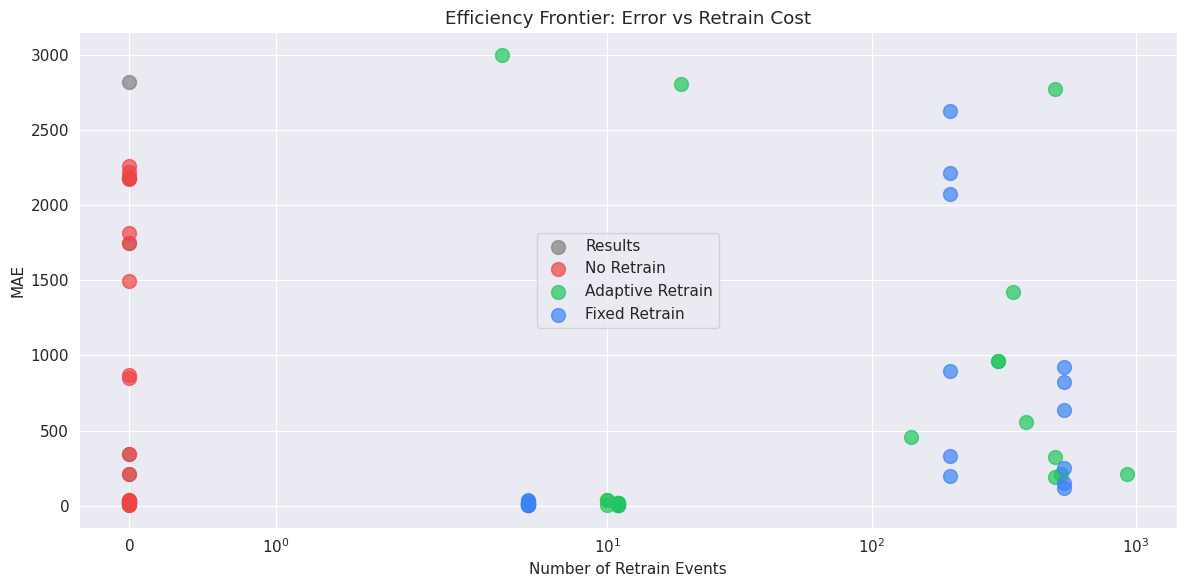


Insight: Ideal solutions are in bottom-left (low error, low retrain count)


In [11]:
fig, ax = plt.subplots()
strategy_colors = {'no_retrain': '#ef4444', 'fixed_retrain': '#3b82f6', 'adaptive_retrain': '#22c55e'}

for strategy in df['strategy'].unique():
    subset = df[df['strategy'] == strategy]
    ax.scatter(subset['retrain_count'], subset['mae'], 
               c=strategy_colors.get(strategy, 'gray'), 
               label=strategy.replace('_', ' ').title(), 
               alpha=0.7, s=100)

ax.set_xlabel('Number of Retrain Events')
ax.set_ylabel('MAE')
ax.set_title('Efficiency Frontier: Error vs Retrain Cost')
ax.legend()
ax.set_xscale('symlog')
plt.tight_layout()
plt.show()
print("\nInsight: Ideal solutions are in bottom-left (low error, low retrain count)")

## 8. Key Findings Summary

In [12]:
print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)

best_model = model_rankings.index[0]
best_model_mae = model_rankings.iloc[0]['mae']
print(f"\n1. Best Model: {best_model} (avg MAE: {best_model_mae:.2f})")

best_strategy = strategy_rankings.index[0]
best_strategy_mae = strategy_rankings.iloc[0]['mae']
print(f"2. Best Strategy: {best_strategy.replace('_', ' ').title()} (avg MAE: {best_strategy_mae:.2f})")

adaptive_wins_count = len(comp_df[comp_df['improvement_pct'] > 10])
print(f"3. Adaptive beats Fixed (>10%): {adaptive_wins_count} cases")

top_configs = best_per_dataset[['dataset', 'model', 'strategy', 'mae']].values
print(f"4. Best per dataset:")
for ds, m, s, mae in top_configs:
    print(f"   - {ds}: {m} + {s.replace('_', ' ')} (MAE: {mae:.2f})")

print("=" * 60)

KEY FINDINGS

1. Best Model: lgbm (avg MAE: 206.72)
2. Best Strategy: Fixed Retrain (avg MAE: 475.67)
3. Adaptive beats Fixed (>10%): 5 cases
4. Best per dataset:
   - ..: test_lgbm + results (MAE: 212.71)
   - brent: tsmixer + adaptive retrain (MAE: 1.39)
   - electricity: lgbm + fixed retrain (MAE: 119.53)
   - traffic: lgbm + adaptive retrain (MAE: 190.89)
   - wti: tsmixer + fixed retrain (MAE: 1.37)


## 9. Export Summary Tables

In [13]:
# Export full comparison table
comp_df.to_csv('adaptive_vs_fixed_comparison.csv', index=False)
print("Exported: adaptive_vs_fixed_comparison.csv")

# Export model rankings
model_rankings.to_csv('model_rankings.csv')
print("Exported: model_rankings.csv")

# Export pivot table
pivot.to_csv('mae_heatmap_data.csv')
print("Exported: mae_heatmap_data.csv")

Exported: adaptive_vs_fixed_comparison.csv
Exported: model_rankings.csv
Exported: mae_heatmap_data.csv
